Iniciando procesamiento de 142 galaxias...
OK: 22.40_68.70_shid108013_gas.csv -> Tipo 5
OK: 164.59_42.53_shid462481_gas.csv -> Tipo 2
OK: 28.07_19.26_shid60744_gas.csv -> Tipo 2
OK: 144.03_59.54_shid279708_gas.csv -> Tipo 2
OK: 134.91_60.25_shid76093_gas.csv -> Tipo 2
OK: 74.94_39.30_shid492425_gas.csv -> Tipo 5
OK: 112.20_69.93_shid114398_gas.csv -> Tipo 2
OK: 78.22_51.04_shid467212_gas.csv -> Tipo 3
OK: 120.04_58.50_shid476487_gas.csv -> Tipo 5
OK: 159.11_51.69_shid509468_gas.csv -> Tipo 5
OK: 85.67_62.69_shid462775_gas.csv -> Tipo 5
OK: 37.02_49.13_shid501215_gas.csv -> Tipo 5
OK: 0.00_39.07_shid212838_gas.csv -> Tipo 2
OK: 111.05_46.76_shid475906_gas.csv -> Tipo 5
OK: 87.52_34.06_shid395736_gas.csv -> Tipo 5
OK: 57.09_34.26_shid360510_gas.csv -> Tipo 5
OK: 105.47_29.11_shid420435_gas.csv -> Tipo 5
OK: 38.52_57.54_shid488123_gas.csv -> Tipo 2
OK: 11.37_63.62_shid455335_gas.csv -> Tipo 3
OK: 156.68_50.21_shid485283_gas.csv -> Tipo 2
OK: 99.21_31.35_shid426361_gas.csv -> Tipo 2
OK: 84

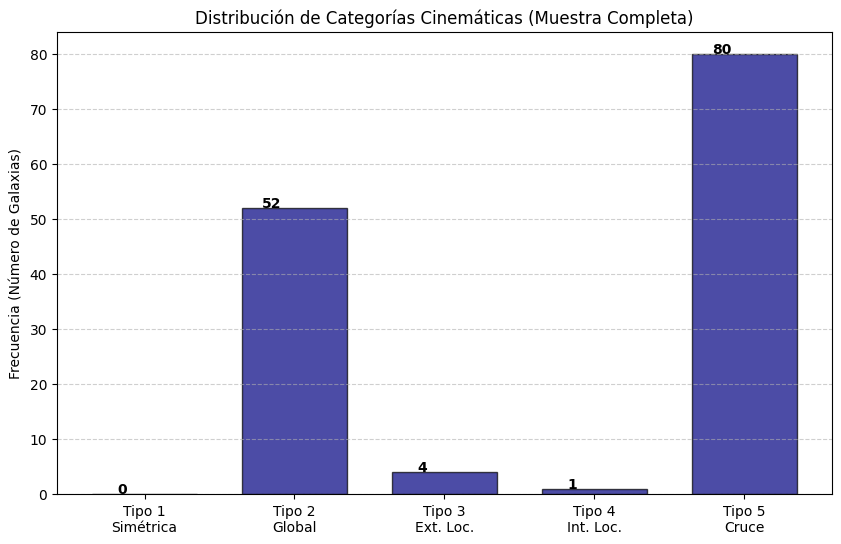

In [2]:
import numpy as np
import pandas as pd
import emcee
import matplotlib.pyplot as plt
import glob
import os



# --- 1. MODELO Y FUNCIONES MCMC ---
def Vrot_model(p, r):
    Vc, Rt, sout, sigma = p
    return Vc * np.tanh(r / Rt) + sout * r

def log_posterior(p, r, Vrot):
    Vc, Rt, sout, sigma = p
    if not (0 < Vc < 600 and 0.1 < Rt < 50 and -5 < sout < 5 and 0.1 < sigma < 100):
        return -np.inf
    model = Vrot_model(p, r)
    return -0.5 * np.sum(((Vrot - model)**2 / sigma**2) + np.log(2 * np.pi * sigma**2))

def run_mcmc(r_data, V_data, label):
    if len(r_data) < 15: # Aumentado ligeramente para estabilidad
        return None
    p0 = [200, 2.0, 0.0, 25.0]
    ndim, nwalkers = 4, 32 # Reducido para velocidad en procesamiento por lotes
    pos = p0 + np.array([20, 0.5, 1.0, 5.0]) * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(r_data, V_data))
    sampler.run_mcmc(pos, 1500, progress=False)
    samples = sampler.get_chain(discard=500, thin=15, flat=True)
    return np.median(samples, axis=0)

# --- 2. LÓGICA DE CLASIFICACIÓN (van Eymeren et al. 2011) ---
def clasificar_whisp(r_eval, v_pos, v_neg):
    resta = v_pos - v_neg
    abs_resta = np.abs(resta)
    umbral = 5.0 # Diferencia significativa en km/s [cite: 351]

    # Tipo 5: Las curvas cambian de lado (cruce) [cite: 19, 22]
    if np.any(resta[:-1] * resta[1:] < 0):
        return 5
    # Tipo 1: Casi idénticas (Simétricas) 
    if np.all(abs_resta < umbral):
        return 1
    
    # Análisis de zonas para Tipos 3 y 4 
    diff_interna = np.mean(abs_resta[:len(abs_resta)//4])
    diff_externa = np.mean(abs_resta[-len(abs_resta)//4:])
    
    if diff_interna < umbral and diff_externa >= umbral:
        return 3 # Distorsión local externa 
    elif diff_interna >= umbral and diff_externa < umbral:
        return 4 # Distorsión local interna 
    else:
        return 2 # Desplazamiento global constante 

# --- 3. BUCLE DE PROCESAMIENTO POR LOTES ---
archivos = glob.glob("*.csv")
clasificaciones = []

print(f"Iniciando procesamiento de {len(archivos)} galaxias...")
with open("cls99.txt", "w") as report_file:
    for fname in archivos:
        try:
            parts = fname.replace(".csv","").split("_")
            phi0_deg, i_deg = float(parts[0]), float(parts[1])
            subhalo_id = int(parts[2].replace("shid", ""))
            df = pd.read_csv(fname)
            
            # Geometría y Deproyección
            i_rad, phi0_rad = np.radians(i_deg), np.radians(phi0_deg)
            phi_diff = df["phi_rad"].values - phi0_rad
            projection = np.sin(i_rad) * np.cos(phi_diff)
            mask_cone = np.abs(np.cos(phi_diff)) >= np.cos(np.radians(60))
            
            # Separación Lado Rojo (+) y Azul (-)
            m_pos = (projection > 0) & mask_cone
            m_neg = (projection < 0) & mask_cone
            
            r_pos, v_pos_data = df["r_kpc"].values[m_pos], np.abs(df["Vobs_kms"].values[m_pos] / projection[m_pos])
            r_neg, v_neg_data = df["r_kpc"].values[m_neg], np.abs(df["Vobs_kms"].values[m_neg] / projection[m_neg])
            
            # Ajustes MCMC Independientes
            fit_pos = run_mcmc(r_pos, v_pos_data, "Pos")
            fit_neg = run_mcmc(r_neg, v_neg_data, "Neg")
            
            if fit_pos is not None and fit_neg is not None:
                r_eval = np.linspace(0.1, np.max(df["r_kpc"]), 100)
                v_model_pos = Vrot_model(fit_pos, r_eval)
                v_model_neg = Vrot_model(fit_neg, r_eval)
                
                categoria = clasificar_whisp(r_eval, v_model_pos, v_model_neg)
                clasificaciones.append(categoria)
                print(f"OK: {fname} -> Tipo {categoria}")
                report_file.write(f"Tipo{categoria} {subhalo_id}\n")
                
        except Exception as e:
            print(f"ERROR en {fname}: {e}")
report_file.close()
# --- 4. HISTOGRAMA DE RESULTADOS ---
plt.figure(figsize=(10, 6))
labels = ['Tipo 1\nSimétrica', 'Tipo 2\nGlobal', 'Tipo 3\nExt. Loc.', 'Tipo 4\nInt. Loc.', 'Tipo 5\nCruce']
counts, bins, _ = plt.hist(clasificaciones, bins=np.arange(1, 7)-0.5, rwidth=0.7, color='navy', alpha=0.7, edgecolor='black')

plt.xticks(range(1, 6), labels)
plt.ylabel("Frecuencia (Número de Galaxias)")
plt.title("Distribución de Categorías Cinemáticas (Muestra Completa)")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Añadir etiquetas de conteo
for i in range(len(counts)):
    plt.text(bins[i]+0.35, counts[i] + 0.1, str(int(counts[i])), ha='center', fontweight='bold')

plt.show()